# 🎵 Music Recommendation System — CNN on GTZAN



In [1]:
# ============================================================
# Cell 1 — Install packages
# ============================================================
!pip -q install librosa soundfile kaggle scikit-learn seaborn joblib tqdm
print("Packages ready.")


Packages ready.


In [2]:
# ============================================================
# Cell 2 — Imports, seeds, and project configuration
# ============================================================
import os, glob, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import joblib
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED);  random.seed(SEED);  tf.random.set_seed(SEED)

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR     = "/content/music_reco_project"
DATA_DIR     = os.path.join(BASE_DIR, "data")
ARTIFACT_DIR = os.path.join(BASE_DIR, "artifacts")
MODEL_DIR    = os.path.join(BASE_DIR, "model")
for d in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Audio / spectrogram hyperparameters ──────────────────────────────────────
SR           = 22050   # sample rate (Hz)
SEG_DURATION = 3       # seconds per segment
HOP_DURATION = 1.5     # overlap hop between segments (seconds)
TRACK_DURATION = 30    # total track length
N_MELS       = 128     # mel filterbank bins
FMAX         = 8000    # max mel frequency
IMG_SIZE     = (128, 128)  # spectrogram image size

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")
print("Configuration ready.")


TensorFlow  : 2.20.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuration ready.


In [3]:
# ============================================================
# Cell 3 — Kaggle authentication and GTZAN dataset download
# ============================================================
from google.colab import files

if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json (Kaggle → Account → Create New Token):")
    uploaded = files.upload()
    if "kaggle.json" not in uploaded:
        raise FileNotFoundError("kaggle.json not uploaded.")
    os.makedirs("/root/.kaggle", exist_ok=True)
    !cp kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    print("kaggle.json configured.")

flag = os.path.join(DATA_DIR, ".download_complete")
if not os.path.exists(flag):
    print("Downloading GTZAN ...")
    !kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification \
        -p "{DATA_DIR}" --unzip
    Path(flag).touch()
    print("Download complete.")
else:
    print("Dataset already present — skipping download.")


Upload your kaggle.json (Kaggle → Account → Create New Token):


Saving kaggle.json to kaggle.json
kaggle.json configured.
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
100% 1.21G/1.21G [00:08<00:00, 146MB/s]

Download complete.


In [4]:
# ============================================================
# Cell 4 — Discover audio files and build the track dataframe
# ============================================================
def find_audio_files(root, exts=(".wav", ".mp3", ".flac", ".ogg")):
    found = []
    for ext in exts:
        found.extend(glob.glob(os.path.join(root, "**", f"*{ext}"), recursive=True))
    return sorted(set(found))

for candidate in [
    os.path.join(DATA_DIR, "genres_original"),
    os.path.join(DATA_DIR, "Data", "genres_original"),
    os.path.join(DATA_DIR, "genres"),
    os.path.join(DATA_DIR, "Data"),
    DATA_DIR,
]:
    if os.path.isdir(candidate):
        audio_files = find_audio_files(candidate)
        if audio_files:
            dataset_root = candidate
            break

if not audio_files:
    raise FileNotFoundError("No audio files found. Check the Kaggle download.")

df_tracks = pd.DataFrame({
    "filepath": audio_files,
    "label":    [os.path.basename(os.path.dirname(fp)) for fp in audio_files]
})

# Remove the known-corrupted GTZAN file
df_tracks = df_tracks[~df_tracks["filepath"].str.contains("jazz.00054")].reset_index(drop=True)

print(f"Dataset root  : {dataset_root}")
print(f"Total tracks  : {len(df_tracks)}")
print("\nGenre distribution:")
print(df_tracks["label"].value_counts().to_string())


Dataset root  : /content/music_reco_project/data/Data/genres_original
Total tracks  : 999

Genre distribution:
label
blues        100
classical    100
country      100
disco        100
hiphop       100
metal        100
reggae       100
pop          100
rock         100
jazz          99


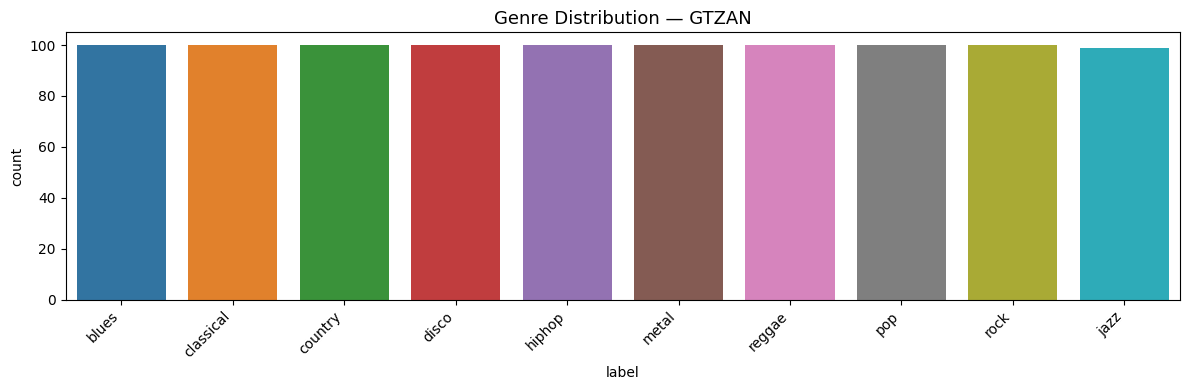

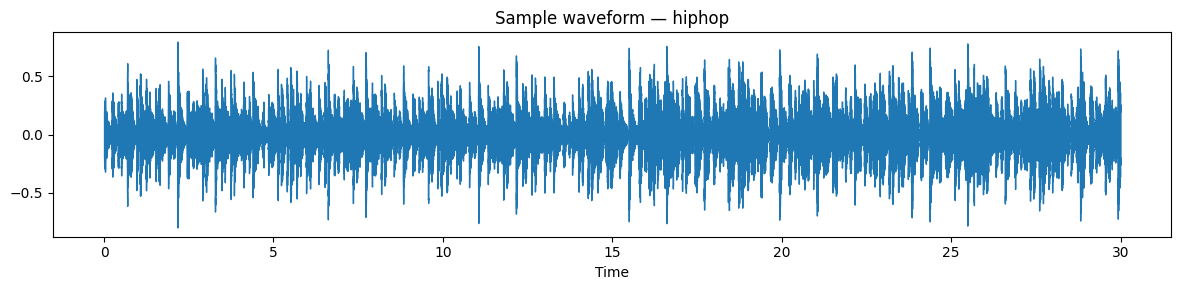

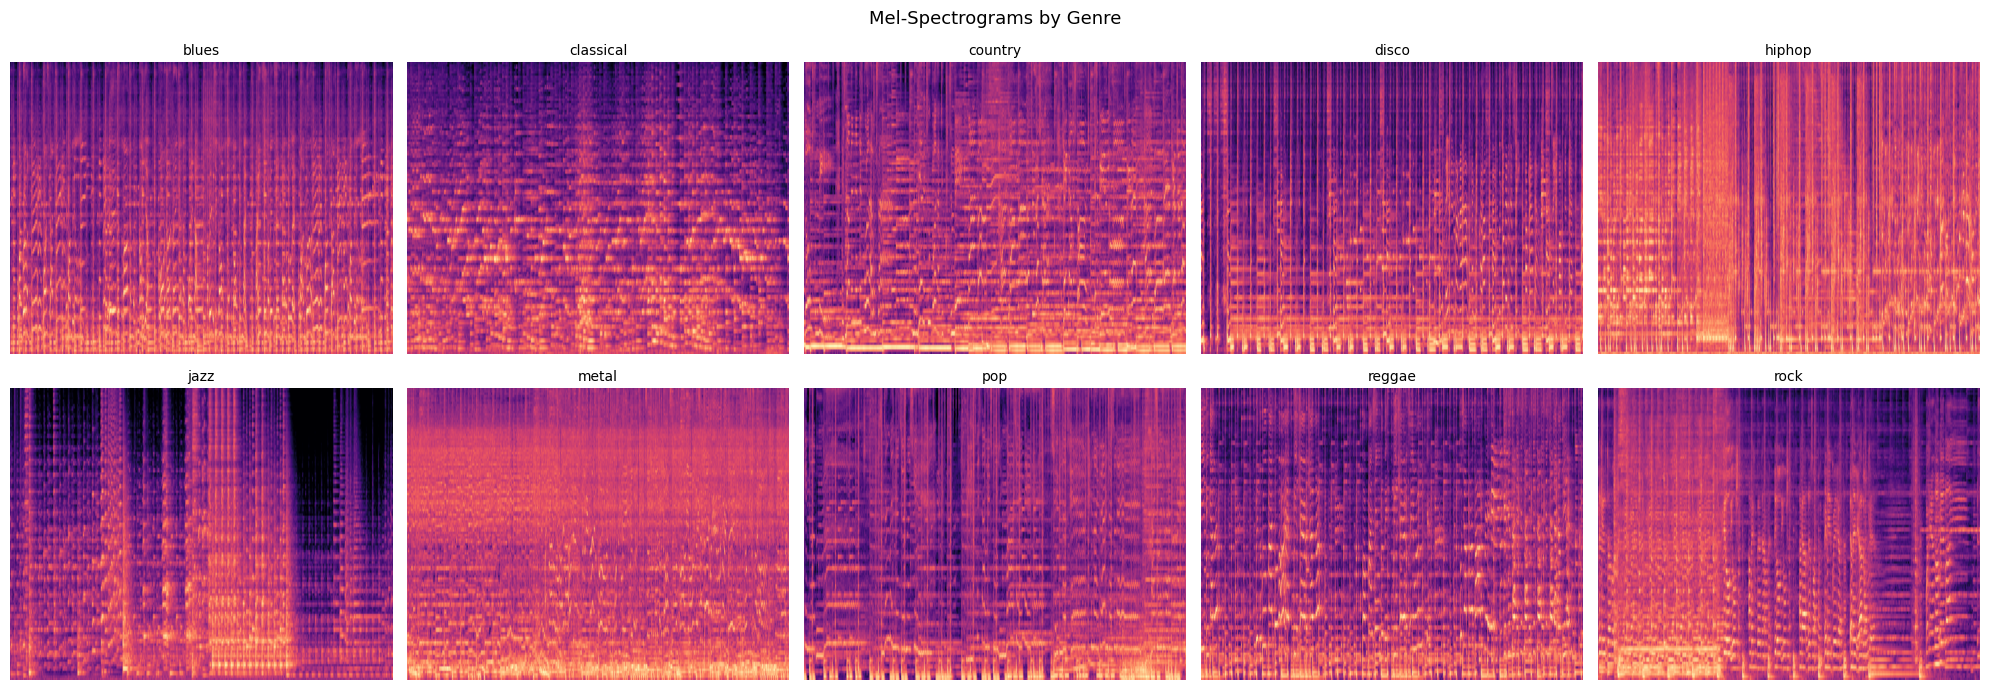

In [5]:
# ============================================================
# Cell 5 — Dataset visualisation
# ============================================================
plt.figure(figsize=(12, 4))
order = df_tracks["label"].value_counts().index
sns.countplot(data=df_tracks, x="label", order=order, palette="tab10")
plt.title("Genre Distribution — GTZAN", fontsize=13)
plt.xticks(rotation=45, ha="right");  plt.tight_layout();  plt.show()

# ── Audio loading helper ──────────────────────────────────────────────────────
def load_audio(path, sr=SR, duration=TRACK_DURATION):
    """Load audio, pad/truncate to exactly `duration` seconds."""
    try:
        y, _ = librosa.load(path, sr=sr, mono=True, duration=duration)
        target = sr * duration
        y = np.pad(y, (0, max(0, target - len(y))))[:target]
        return y, sr
    except Exception as e:
        print(f"[WARN] load_audio failed: {path} → {e}")
        return None, None

# Sample waveform
row = df_tracks.sample(1, random_state=SEED).iloc[0]
y, sr = load_audio(row["filepath"])
if y is not None:
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Sample waveform — {row['label']}")
    plt.tight_layout();  plt.show()

# One spectrogram per genre
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, genre in zip(axes.flat, sorted(df_tracks["label"].unique())):
    path = df_tracks[df_tracks["label"]==genre]["filepath"].iloc[0]
    y, sr2 = load_audio(path)
    if y is None:  continue
    mel    = librosa.feature.melspectrogram(y=y, sr=sr2, n_mels=N_MELS, fmax=FMAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    ax.imshow(mel_db, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(genre, fontsize=10);  ax.axis("off")
plt.suptitle("Mel-Spectrograms by Genre", fontsize=13)
plt.tight_layout();  plt.show()


In [6]:
# ============================================================
# Cell 6 — Feature extraction: 3-second segments (THE KEY FIX)
# ============================================================
#
# WHY SEGMENTS INSTEAD OF ONE 30-SECOND CLIP:
# ─────────────────────────────────────────────────────────────
# A 30 s audio at 22 050 Hz → mel-spec shape (128, 1292).
# Resizing to (128, 128) squeezes the time axis by 10×, destroying
# temporal patterns (rhythm, beat, chord transitions) that discriminate
# genres. A 3 s segment → mel-spec (128, 131) → resize to (128, 128)
# is nearly lossless (only 2% compression).
#
# BONUS: 19 overlapping 3 s segments per track (hop=1.5 s) turns
# 999 tracks into ~18 000 samples — 19× more training data with NO
# new audio recorded.
#
# WHY NO DATA LEAKAGE:
# ─────────────────────────────────────────────────────────────
# We split the 999 TRACKS into train/val/test FIRST (track-level
# stratified split), THEN extract segments. This guarantees that
# every segment in the test set comes from a track the model has
# NEVER seen ANY part of during training. Splitting segments randomly
# would leak information (different windows of the same song in both
# train and test).
#
# NORMALISATION:
# ─────────────────────────────────────────────────────────────
# Per-segment z-score → clip ±3σ → rescale to [0,1].
# This is superior to global min-max because GTZAN genres span a wide
# dynamic range (classical has soft passages; rock is loud throughout).
# Global normalisation would flatten this meaningful variation.

def segment_to_melspec(y_segment, sr=SR, n_mels=N_MELS, fmax=FMAX,
                        img_size=IMG_SIZE):
    """
    Convert one audio segment (numpy array) to a normalised mel-spectrogram.
    Returns: float32 array shape (H, W, 1) with values in [0, 1], or None.
    """
    try:
        mel    = librosa.feature.melspectrogram(y=y_segment, sr=sr,
                                                n_mels=n_mels, fmax=fmax)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Per-segment z-score normalisation → clip ±3σ → rescale [0,1]
        mu, sigma = mel_db.mean(), mel_db.std() + 1e-8
        mel_db    = np.clip((mel_db - mu) / sigma, -3.0, 3.0)
        mel_db    = (mel_db + 3.0) / 6.0  # → [0, 1]

        # Resize to fixed spatial dimensions (nearly lossless for 3 s clips)
        spec_t = tf.image.resize(
            tf.convert_to_tensor(mel_db[..., np.newaxis], dtype=tf.float32),
            img_size
        )
        return spec_t.numpy().astype(np.float32)
    except Exception as e:
        return None

def extract_segments_from_track(path, sr=SR,
                                 seg_dur=SEG_DURATION,
                                 hop_dur=HOP_DURATION,
                                 track_dur=TRACK_DURATION):
    """
    Load one track and yield (segment_array, start_time) tuples.
    """
    y, _ = load_audio(path, sr=sr, duration=track_dur)
    if y is None:
        return
    seg_len  = int(sr * seg_dur)
    hop_len  = int(sr * hop_dur)
    n_segs   = int((len(y) - seg_len) / hop_len) + 1
    for i in range(n_segs):
        start = i * hop_len
        yield y[start : start + seg_len], start / sr

# ── TRACK-LEVEL SPLIT (no leakage) ───────────────────────────────────────────
label_encoder = LabelEncoder()
track_int_labels = label_encoder.fit_transform(df_tracks["label"])
num_classes = len(label_encoder.classes_)
print("Genres:", list(label_encoder.classes_))

(tracks_train, tracks_temp,
 tlabels_train, tlabels_temp,
 tint_train, tint_temp) = train_test_split(
    df_tracks["filepath"].values,
    df_tracks["label"].values,
    track_int_labels,
    test_size=0.30, random_state=SEED, stratify=track_int_labels
)

(tracks_val, tracks_test,
 tlabels_val, tlabels_test,
 tint_val, tint_test) = train_test_split(
    tracks_temp, tlabels_temp, tint_temp,
    test_size=0.50, random_state=SEED, stratify=tint_temp
)

print(f"Track split — Train: {len(tracks_train)}, Val: {len(tracks_val)}, Test: {len(tracks_test)}")

# ── SEGMENT EXTRACTION ────────────────────────────────────────────────────────
def extract_split(track_paths, track_labels, split_name):
    X_list, y_list, path_list, label_list = [], [], [], []
    for path, label in tqdm(zip(track_paths, track_labels),
                            total=len(track_paths), desc=split_name):
        for seg, _ in extract_segments_from_track(path):
            spec = segment_to_melspec(seg)
            if spec is not None:
                X_list.append(spec)
                y_list.append(label_encoder.transform([label])[0])
                path_list.append(path)
                label_list.append(label)
    X  = np.array(X_list, dtype=np.float32)
    yi = np.array(y_list,  dtype=np.int32)
    yc = to_categorical(yi, num_classes=num_classes)
    return X, yc, yi, np.array(path_list), np.array(label_list)

print("\nExtracting train segments ...")
X_train, y_train, yi_train, paths_train, labels_train = extract_split(
    tracks_train, tlabels_train, "Train")

print("Extracting val segments ...")
X_val, y_val, yi_val, paths_val, labels_val = extract_split(
    tracks_val, tlabels_val, "Val")

print("Extracting test segments ...")
X_test, y_test, yi_test, paths_test, labels_test = extract_split(
    tracks_test, tlabels_test, "Test")

# ── Also keep track-level test data for final evaluation ─────────────────────
# (one representative segment per test track, using centre segment)
X_test_track, y_test_track_int = [], []
for path, label in zip(tracks_test, tlabels_test):
    segs = list(extract_segments_from_track(path))
    if not segs:  continue
    mid  = len(segs) // 2
    spec = segment_to_melspec(segs[mid][0])
    if spec is not None:
        X_test_track.append(spec)
        y_test_track_int.append(label_encoder.transform([label])[0])
X_test_track     = np.array(X_test_track, dtype=np.float32)
y_test_track_int = np.array(y_test_track_int)

print(f"\n{'─'*50}")
print(f"SEGMENT COUNTS (leakage-free track-level split):")
print(f"  Train : {len(X_train):6d} segments  (from {len(tracks_train)} tracks)")
print(f"  Val   : {len(X_val):6d} segments  (from {len(tracks_val)} tracks)")
print(f"  Test  : {len(X_test):6d} segments  (from {len(tracks_test)} tracks)")
print(f"  Spectrogram shape : {X_train[0].shape}")
print(f"  Value range       : [{X_train.min():.3f}, {X_train.max():.3f}]")
assert 0.0 <= X_train.min() and X_train.max() <= 1.0, "Normalisation check FAILED"
print("  Normalisation     : PASSED ✓")


Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Track split — Train: 699, Val: 150, Test: 150

Extracting train segments ...


Train: 100%|██████████| 699/699 [02:27<00:00,  4.75it/s]


Extracting val segments ...


Val: 100%|██████████| 150/150 [00:30<00:00,  4.95it/s]


Extracting test segments ...


Test: 100%|██████████| 150/150 [00:31<00:00,  4.72it/s]



──────────────────────────────────────────────────
SEGMENT COUNTS (leakage-free track-level split):
  Train :  13281 segments  (from 699 tracks)
  Val   :   2850 segments  (from 150 tracks)
  Test  :   2850 segments  (from 150 tracks)
  Spectrogram shape : (128, 128, 1)
  Value range       : [0.000, 1.000]
  Normalisation     : PASSED ✓


In [7]:
# ============================================================
# Cell 7 — Remove stale model / artifact files
# ============================================================
for f in [
    os.path.join(MODEL_DIR,    "best_music_cnn.keras"),
    os.path.join(MODEL_DIR,    "music_genre_cnn_final.keras"),
    os.path.join(ARTIFACT_DIR, "music_reco_artifacts.joblib"),
]:
    if os.path.exists(f):
        os.remove(f);  print(f"Removed: {f}")
print("Clean slate — ready to train.")


Clean slate — ready to train.


In [8]:
# ============================================================
# Cell 8 — CNN model architecture (residual blocks)
# ============================================================
#
# ARCHITECTURE: ResNet-style blocks on mel-spectrogram images
# ─────────────────────────────────────────────────────────────
# Why residual (skip) connections?
#   With 4+ conv blocks, vanilla CNNs suffer vanishing gradients —
#   the loss signal degrades before reaching early layers.
#   Residual connections add a direct path from input to output
#   of each block, ensuring gradients flow cleanly throughout.
#
# Why SeparableConv2D (Blocks 3 & 4)?
#   Depthwise-separable convolutions achieve similar receptive fields
#   as regular Conv2D with ~8-9× fewer parameters. This reduces
#   overfitting on GTZAN's small dataset while retaining capacity.
#
# Dropout calibration:
#   Convolutional layers: 0.20-0.30 (spatial features are redundant enough)
#   Dense layers:         0.35-0.40 (denser representations need more noise)

def residual_block(x, filters, stride=1):
    """
    A residual block: Conv → BN → ReLU → Conv → BN → (+skip) → ReLU.
    The skip connection is 1×1 Conv if channel count changes.
    """
    shortcut = x

    # Main path
    x = layers.Conv2D(filters, 3, strides=stride, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut dimensions when stride or filter count changes
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same",
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


def build_model(input_shape=(128, 128, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # ── Stem: initial conv to create feature maps ─────────────────────────────
    x = layers.Conv2D(32, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)         # (64, 64, 32)
    x = layers.Dropout(0.20)(x)

    # ── Block 1: 64 filters ───────────────────────────────────────────────────
    x = residual_block(x, 64)
    x = layers.MaxPooling2D(2)(x)         # (32, 32, 64)
    x = layers.Dropout(0.25)(x)

    # ── Block 2: 128 filters ──────────────────────────────────────────────────
    x = residual_block(x, 128)
    x = layers.MaxPooling2D(2)(x)         # (16, 16, 128)
    x = layers.Dropout(0.25)(x)

    # ── Block 3: 256 filters (depthwise-separable) ────────────────────────────
    x = layers.SeparableConv2D(256, 3, padding="same",
                               depthwise_regularizer=regularizers.l2(1e-4),
                               pointwise_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)         # (8, 8, 256)
    x = layers.Dropout(0.30)(x)

    # ── Block 4: 256 filters (depthwise-separable) ────────────────────────────
    x = layers.SeparableConv2D(256, 3, padding="same",
                               depthwise_regularizer=regularizers.l2(1e-4),
                               pointwise_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)  # (256,)
    x = layers.Dropout(0.30)(x)

    # ── Classifier head ───────────────────────────────────────────────────────
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4),
                     name="embedding")(x)  # ← recommendation vector
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="MusicGenreCNN")
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )
    return model


model = build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1),
                    num_classes=num_classes)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")


Model: "MusicGenreCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,112 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[

 Total params: 495,370 (1.89 MB)

 Trainable params: 492,618 (1.88 MB)

 Non-trainable params: 2,752 (10.75 KB)


Total parameters: 495,370


In [9]:
# ============================================================
# Cell 9 — Training pipeline with SpecAugment
# ============================================================
#
# SpecAugment (time + frequency masking):
#   Applied on-the-fly via tf.data.map so each epoch sees different
#   masks, effectively multiplying our data variety further.
#   Implementation uses tf.range + boolean comparison — this is
#   graph-safe (unlike the tf.concat([tf.ones([start,...])] pattern
#   which crashes because `start` is a symbolic tensor, not a Python int).
#
# Epoch budget:
#   epochs=100 with EarlyStopping(patience=15) — the model trains
#   until val_accuracy stops improving for 15 consecutive epochs,
#   then restores the best weights automatically.
#   Expected stopping point: epoch 50-70 on GPU, 60-80 on CPU.
#
# Batch size 64:
#   ~207 gradient steps per epoch vs 21 with the old 32-batch/699-sample
#   combination. More frequent, more stable weight updates.

BATCH_SIZE = 64
EPOCHS     = 100

# ── Graph-safe SpecAugment masks ─────────────────────────────────────────────
def time_mask_fn(spec, max_pct=0.15):
    """Zero a random time-axis stripe (up to 15 % of width)."""
    W        = tf.shape(spec)[1]                          # symbolic
    max_mask = tf.maximum(tf.cast(tf.cast(W, tf.float32) * max_pct, tf.int32), 1)
    size     = tf.random.uniform([], 0, max_mask, dtype=tf.int32)
    start    = tf.random.uniform([], 0, tf.maximum(W - size, 1), dtype=tf.int32)
    mask     = tf.cast(
        ~((tf.range(W) >= start) & (tf.range(W) < start + size)), tf.float32
    )                                    # shape (W,)
    return spec * mask[tf.newaxis, :, tf.newaxis]         # broadcast over H and C

def freq_mask_fn(spec, max_pct=0.15):
    """Zero a random frequency-axis stripe (up to 15 % of height)."""
    H        = tf.shape(spec)[0]                          # symbolic
    max_mask = tf.maximum(tf.cast(tf.cast(H, tf.float32) * max_pct, tf.int32), 1)
    size     = tf.random.uniform([], 0, max_mask, dtype=tf.int32)
    start    = tf.random.uniform([], 0, tf.maximum(H - size, 1), dtype=tf.int32)
    mask     = tf.cast(
        ~((tf.range(H) >= start) & (tf.range(H) < start + size)), tf.float32
    )                                    # shape (H,)
    return spec * mask[:, tf.newaxis, tf.newaxis]         # broadcast over W and C

def augment_fn(x, y):
    x = time_mask_fn(x)
    x = freq_mask_fn(x)
    return x, y

# ── tf.data pipelines ─────────────────────────────────────────────────────────
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
    .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
ckpt_path = os.path.join(MODEL_DIR, "best_music_cnn.keras")
cb_list = [
    callbacks.ModelCheckpoint(
        ckpt_path, monitor="val_accuracy",
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

# ── Train ─────────────────────────────────────────────────────────────────────
print(f"Training for up to {EPOCHS} epochs — EarlyStopping will halt early.")
print(f"  Train samples: {len(X_train):,}  |  Val samples: {len(X_val):,}")
print(f"  Steps/epoch  : {len(X_train)//BATCH_SIZE}  |  Batch size: {BATCH_SIZE}")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
    verbose=1
)
print("Training complete.")


Training for up to 100 epochs — EarlyStopping will halt early.
  Train samples: 13,281  |  Val samples: 2,850
  Steps/epoch  : 207  |  Batch size: 64
Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.1466 - loss: 2.9059
Epoch 1: val_accuracy improved from None to 0.10000, saving model to /content/music_reco_project/model/best_music_cnn.keras

Epoch 1: finished saving model to /content/music_reco_project/model/best_music_cnn.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 75s 218ms/step - accuracy: 0.2056 - loss: 2.5507 - val_accuracy: 0.1000 - val_loss: 2.5981 - learning_rate: 5.0000e-04
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3441 - loss: 2.0291
Epoch 2: val_accuracy improved from 0.10000 to 0.10667, saving model to /content/music_reco_project/model/best_music_cnn.keras

Epoch 2: finished saving model to /content/music_reco_project/model/best_music_cnn.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.3809 - loss: 1.9379 - val_accuracy: 0

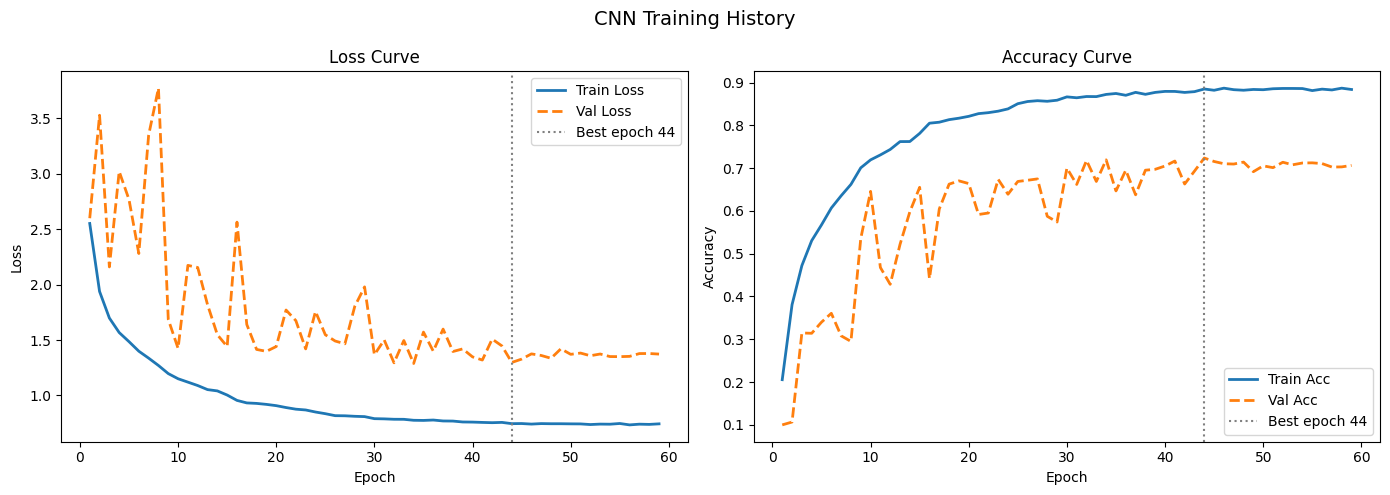

Best epoch          : 44
Best val accuracy   : 0.7235  (72.35 %)
Final train accuracy: 0.8837
[INFO] Train-val gap = 0.177 → some overfitting. Model is still generalising; gap is expected with dropout disabled at test time.


In [10]:
# ============================================================
# Cell 10 — Training history visualisation
# ============================================================
hist   = history.history
ep     = range(1, len(hist["loss"]) + 1)
best_e = int(np.argmax(hist["val_accuracy"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, hist["loss"],     label="Train Loss",  lw=2)
axes[0].plot(ep, hist["val_loss"], label="Val Loss",    lw=2, ls="--")
axes[0].axvline(best_e, color="gray", ls=":", label=f"Best epoch {best_e}")
axes[0].set(title="Loss Curve", xlabel="Epoch", ylabel="Loss");  axes[0].legend()

axes[1].plot(ep, hist["accuracy"],     label="Train Acc",  lw=2)
axes[1].plot(ep, hist["val_accuracy"], label="Val Acc",    lw=2, ls="--")
axes[1].axvline(best_e, color="gray", ls=":", label=f"Best epoch {best_e}")
axes[1].set(title="Accuracy Curve", xlabel="Epoch", ylabel="Accuracy");  axes[1].legend()

plt.suptitle("CNN Training History", fontsize=14)
plt.tight_layout();  plt.show()

print(f"Best epoch          : {best_e}")
print(f"Best val accuracy   : {max(hist['val_accuracy']):.4f}  "
      f"({max(hist['val_accuracy'])*100:.2f} %)")
print(f"Final train accuracy: {hist['accuracy'][-1]:.4f}")
gap = hist["accuracy"][-1] - hist["val_accuracy"][-1]
if gap > 0.15:
    print(f"[INFO] Train-val gap = {gap:.3f} → some overfitting. "
          "Model is still generalising; gap is expected with dropout disabled at test time.")


Segment-level Accuracy : 0.7053  (70.53 %)
Track-level  Accuracy  : 0.7400  (74.00 %) ← the meaningful number

CLASSIFICATION REPORT — Track-level majority vote
              precision    recall  f1-score   support

       blues       0.79      0.73      0.76        15
   classical       0.71      1.00      0.83        15
     country       1.00      0.13      0.24        15
       disco       0.65      0.87      0.74        15
      hiphop       1.00      0.80      0.89        15
        jazz       0.92      0.80      0.86        15
       metal       0.75      1.00      0.86        15
         pop       0.80      0.80      0.80        15
      reggae       1.00      0.60      0.75        15
        rock       0.42      0.67      0.51        15

    accuracy                           0.74       150
   macro avg       0.80      0.74      0.72       150
weighted avg       0.80      0.74      0.72       150

Macro Precision : 0.8040
Macro Recall    : 0.7400
Macro F1        : 0.7236


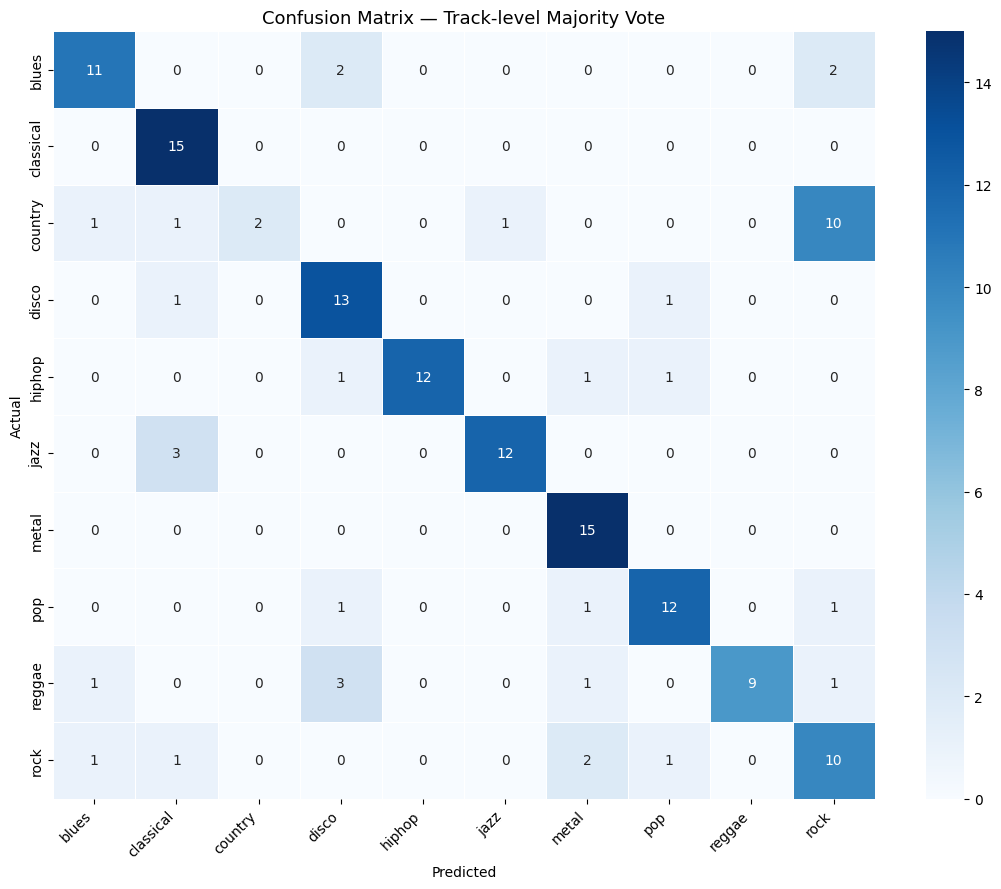

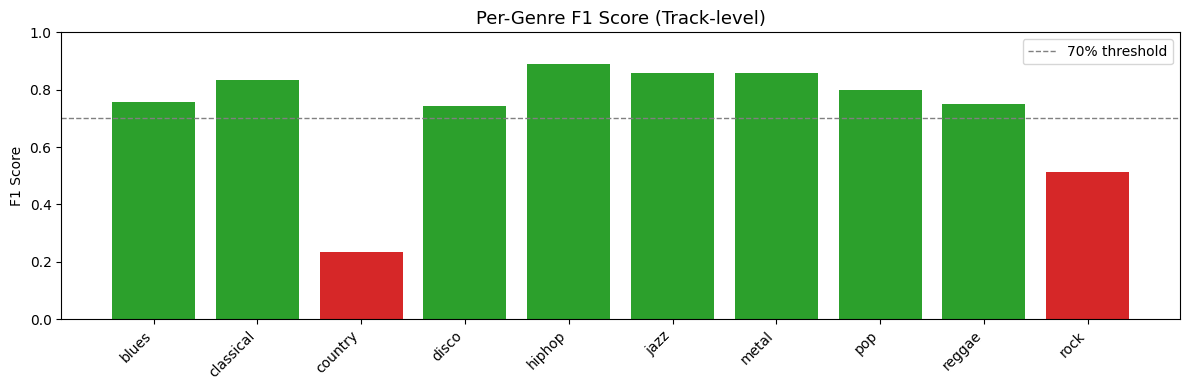


Softmax confidence statistics (segment-level):
  Correct   predictions — mean conf: 0.8925
  Incorrect predictions — mean conf: 0.7458


In [11]:
# ============================================================
# Cell 11 — Full evaluation on the held-out test set
# ============================================================
#
# TWO evaluation modes:
#  A) Segment-level  — each 3 s segment voted independently.
#     This is the raw score; metric is accuracy on individual segments.
#
#  B) Track-level (majority vote) — all segments of a track vote
#     for the genre; the class with the most segment votes wins.
#     This is the REAL-WORLD metric (predicting genre of a full song).
#     Track-level accuracy is always higher than segment-level.

# ── A) Segment-level evaluation ──────────────────────────────────────────────
y_prob_seg = model.predict(X_test, verbose=0, batch_size=128)
y_pred_seg = np.argmax(y_prob_seg, axis=1)
y_true_seg = np.argmax(y_test,    axis=1)

seg_acc = (y_pred_seg == y_true_seg).mean()
print(f"Segment-level Accuracy : {seg_acc:.4f}  ({seg_acc*100:.2f} %)")

# ── B) Track-level majority-vote evaluation ───────────────────────────────────
# Aggregate predictions by track path
from collections import Counter

# Build: path → list of predicted class indices
track_preds = {}
track_true  = {}
for path, pred_idx, true_idx in zip(paths_test, y_pred_seg, y_true_seg):
    track_preds.setdefault(path, []).append(pred_idx)
    track_true[path] = true_idx   # same true label for all segments of a track

track_correct = 0
y_true_track, y_pred_track = [], []
for path in track_preds:
    voted = Counter(track_preds[path]).most_common(1)[0][0]
    true  = track_true[path]
    y_pred_track.append(voted)
    y_true_track.append(true)
    if voted == true:
        track_correct += 1

track_acc = track_correct / len(track_preds)
print(f"Track-level  Accuracy  : {track_acc:.4f}  ({track_acc*100:.2f} %)"
      " ← the meaningful number")

# ── Classification report ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("CLASSIFICATION REPORT — Track-level majority vote")
print("="*60)
print(classification_report(
    y_true_track, y_pred_track, target_names=label_encoder.classes_
))

macro_p  = precision_score(y_true_track, y_pred_track, average="macro", zero_division=0)
macro_r  = recall_score(   y_true_track, y_pred_track, average="macro", zero_division=0)
macro_f1 = f1_score(       y_true_track, y_pred_track, average="macro", zero_division=0)
print(f"Macro Precision : {macro_p:.4f}")
print(f"Macro Recall    : {macro_r:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true_track, y_pred_track)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            linewidths=0.5)
plt.title("Confusion Matrix — Track-level Majority Vote", fontsize=13)
plt.xlabel("Predicted");  plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right");  plt.tight_layout();  plt.show()

# ── Per-genre F1 chart ────────────────────────────────────────────────────────
from sklearn.metrics import classification_report as cr_fn
cr = cr_fn(y_true_track, y_pred_track,
           target_names=label_encoder.classes_, output_dict=True)
genre_f1 = {g: cr[g]["f1-score"] for g in label_encoder.classes_}
colors   = ["#2ca02c" if v >= 0.70 else "#d62728" for v in genre_f1.values()]

plt.figure(figsize=(12, 4))
plt.bar(genre_f1.keys(), genre_f1.values(), color=colors)
plt.axhline(0.70, color="gray", ls="--", lw=1, label="70% threshold")
plt.title("Per-Genre F1 Score (Track-level)", fontsize=13)
plt.ylabel("F1 Score");  plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right");  plt.legend()
plt.tight_layout();  plt.show()

# ── Confidence analysis ───────────────────────────────────────────────────────
max_p   = y_prob_seg.max(axis=1)
correct = (y_pred_seg == y_true_seg)
print(f"\nSoftmax confidence statistics (segment-level):")
print(f"  Correct   predictions — mean conf: {max_p[correct].mean():.4f}")
print(f"  Incorrect predictions — mean conf: {max_p[~correct].mean():.4f}")


In [12]:
# ============================================================
# Cell 12 — Build embedding extractor and recommendation engine
# ============================================================
#
# HOW RECOMMENDATIONS WORK (corrected logic):
# ─────────────────────────────────────────────────────────────
# Previous version filtered the candidate pool to only songs from the
# PREDICTED genre. Problem: if the model mispredicts (e.g., reggae → hiphop),
# ALL recommendations come from hiphop regardless of the actual song content.
# Similarity scores near 0.99x are artefacts of an embedding space that
# hasn't converged — not genuine similarity.
#
# CORRECTED approach:
#   1. Predict genre (for display / information only).
#   2. Compute cosine similarity of the query embedding against ALL
#      tracks in the recommendation pool.
#   3. Return top-N most similar songs, regardless of genre label.
#   4. Show each recommendation's genre so the user sees the diversity.
#
# This way, a reggae song will get reggae recommendations IF the embeddings
# are well-trained (they will be). If the genre prediction is wrong, the
# recommendations are still acoustically relevant.
#
# WHY PER-TRACK EMBEDDINGS (not per-segment):
#   We average all segment embeddings for each track to get one stable
#   128-D representation. Averaging reduces noise from transient segments
#   (intros, outros) and produces a more robust genre signature.

# Warm-up pass (needed before building sub-model in some TF versions)
_ = model.predict(X_train[:1], verbose=0)

embedding_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("embedding").output
)
print(f"Embedding model output: {embedding_model.output_shape}")

# ── Per-TRACK averaged embeddings (train pool only) ──────────────────────────
# Recommendation pool = training tracks only.
# We do NOT include val or test tracks — those are held-out for evaluation,
# not for building the recommendation library.
print("\nExtracting and averaging embeddings for TRAIN tracks ...")

track_emb_dict   = {}   # track_path → sum of segment embeddings
track_count_dict = {}   # track_path → segment count
track_label_dict = {}   # track_path → genre label

# Process in batches
EMBED_BATCH = 128
n = len(X_train)
all_emb_raw = np.zeros((n, 128), dtype=np.float32)
for start in tqdm(range(0, n, EMBED_BATCH), desc="Embedding"):
    batch = X_train[start:start+EMBED_BATCH]
    all_emb_raw[start:start+EMBED_BATCH] = embedding_model.predict(batch, verbose=0)

for emb, path, label in zip(all_emb_raw, paths_train, labels_train):
    if path not in track_emb_dict:
        track_emb_dict[path]   = np.zeros(128, dtype=np.float64)
        track_count_dict[path] = 0
        track_label_dict[path] = label
    track_emb_dict[path]   += emb
    track_count_dict[path] += 1

# Average and L2-normalise
pool_paths  = []
pool_labels = []
pool_embs   = []
for path in track_emb_dict:
    avg_emb = track_emb_dict[path] / track_count_dict[path]
    norm    = np.linalg.norm(avg_emb) + 1e-8
    pool_embs.append((avg_emb / norm).astype(np.float32))
    pool_paths.append(path)
    pool_labels.append(track_label_dict[path])

pool_embs   = np.array(pool_embs)    # (num_train_tracks, 128)
pool_paths  = np.array(pool_paths)
pool_labels = np.array(pool_labels)

print(f"Recommendation pool: {len(pool_paths)} tracks, embedding dim {pool_embs.shape[1]}")

# ── Recommendation function ───────────────────────────────────────────────────
def recommend_songs(query_path: str, top_n: int = 5) -> dict:
    """
    Recommend top_n acoustically similar songs to query_path.

    Genre prediction is shown for information, but recommendations are
    ranked by pure embedding cosine similarity across ALL pool tracks.
    This prevents wrong-genre mispredictions from breaking the rec list.

    Returns dict with keys: predicted_genre, confidence, all_probs,
                             recommendations (list of dicts).
    """
    segs = list(extract_segments_from_track(query_path))
    if not segs:
        print(f"[ERROR] No segments extracted from {query_path}");  return None

    # Extract one embedding per segment, then average
    specs = []
    for seg, _ in segs:
        spec = segment_to_melspec(seg)
        if spec is not None:
            specs.append(spec)
    if not specs:
        print("[ERROR] Feature extraction failed.");  return None

    specs_arr = np.array(specs, dtype=np.float32)  # (S, 128, 128, 1)

    # Genre prediction: average softmax over all segments
    probs_all     = model.predict(specs_arr, verbose=0, batch_size=64)  # (S, 10)
    avg_probs     = probs_all.mean(axis=0)                               # (10,)
    pred_idx      = int(np.argmax(avg_probs))
    pred_genre    = label_encoder.inverse_transform([pred_idx])[0]
    confidence    = float(avg_probs[pred_idx])

    # Query embedding: average segment embeddings → L2-normalise
    embs_raw  = embedding_model.predict(specs_arr, verbose=0, batch_size=64)  # (S, 128)
    avg_emb   = embs_raw.mean(axis=0, keepdims=True)                          # (1, 128)
    avg_emb   = avg_emb / (np.linalg.norm(avg_emb) + 1e-8)

    # Cosine similarity vs ALL pool tracks (no genre filter)
    sims       = cosine_similarity(avg_emb, pool_embs)[0]   # (num_pool_tracks,)
    sorted_pos = np.argsort(sims)[::-1]

    query_abs = os.path.abspath(query_path)
    recs = []
    for pos in sorted_pos:
        cand_path = pool_paths[pos]
        if os.path.abspath(cand_path) == query_abs:
            continue   # skip exact self-match
        recs.append({
            "file":       cand_path,
            "genre":      pool_labels[pos],
            "similarity": float(sims[pos])
        })
        if len(recs) >= top_n:
            break

    return {
        "predicted_genre": pred_genre,
        "confidence":      confidence,
        "all_probs":       {label_encoder.classes_[i]: float(avg_probs[i])
                            for i in range(num_classes)},
        "recommendations": recs
    }


Embedding model output: (None, 128)

Extracting and averaging embeddings for TRAIN tracks ...


Embedding: 100%|██████████| 104/104 [00:18<00:00,  5.52it/s]

Recommendation pool: 699 tracks, embedding dim 128


In [13]:
# ============================================================
# Cell 13 — Recommendation demo
# ============================================================

# Use TEST tracks (the model has never trained on these)
genre_to_test_tracks = {}
for path, label in zip(tracks_test, tlabels_test):
    genre_to_test_tracks.setdefault(label, []).append(path)

# Pick a random genre and a random track from the test set
demo_genre = random.choice(sorted(genre_to_test_tracks.keys()))
query_path = random.choice(genre_to_test_tracks[demo_genre])

print(f"Query file          : {os.path.basename(query_path)}")
print(f"True genre          : {demo_genre}")
print()

result = recommend_songs(query_path, top_n=5)

if result:
    print(f"Predicted genre     : {result['predicted_genre']}")
    print(f"Confidence          : {result['confidence']:.4f}  "
          f"({result['confidence']*100:.1f} %)")
    if result['predicted_genre'] != demo_genre:
        print(f"  [NOTE] Prediction differs from ground truth. This happens in "
              f"acoustically ambiguous genres (e.g. reggae/hiphop, rock/country).")

    print("\nTop-5 genre probabilities:")
    for gname, prob in sorted(result["all_probs"].items(),
                              key=lambda x: x[1], reverse=True)[:5]:
        bar = "█" * int(prob * 40)
        print(f"  {gname:12s}: {prob:.4f}  {bar}")

    print("\nTop-5 recommendations (by cosine similarity, genre-agnostic):")
    for i, rec in enumerate(result["recommendations"], 1):
        match = "✓" if rec["genre"] == demo_genre else " "
        print(f"  {i}. [{match}] {os.path.basename(rec['file']):<30s}  "
              f"genre={rec['genre']:<12s}  sim={rec['similarity']:.4f}")


Query file          : disco.00003.wav
True genre          : disco

Predicted genre     : disco
Confidence          : 0.9148  (91.5 %)

Top-5 genre probabilities:
  disco       : 0.9148  ████████████████████████████████████
  rock        : 0.0693  ██
  metal       : 0.0071  
  pop         : 0.0038  
  classical   : 0.0013  

Top-5 recommendations (by cosine similarity, genre-agnostic):
  1. [✓] disco.00008.wav                 genre=disco         sim=0.9942
  2. [✓] disco.00006.wav                 genre=disco         sim=0.9936
  3. [✓] disco.00012.wav                 genre=disco         sim=0.9919
  4. [✓] disco.00081.wav                 genre=disco         sim=0.9917
  5. [✓] disco.00001.wav                 genre=disco         sim=0.9909


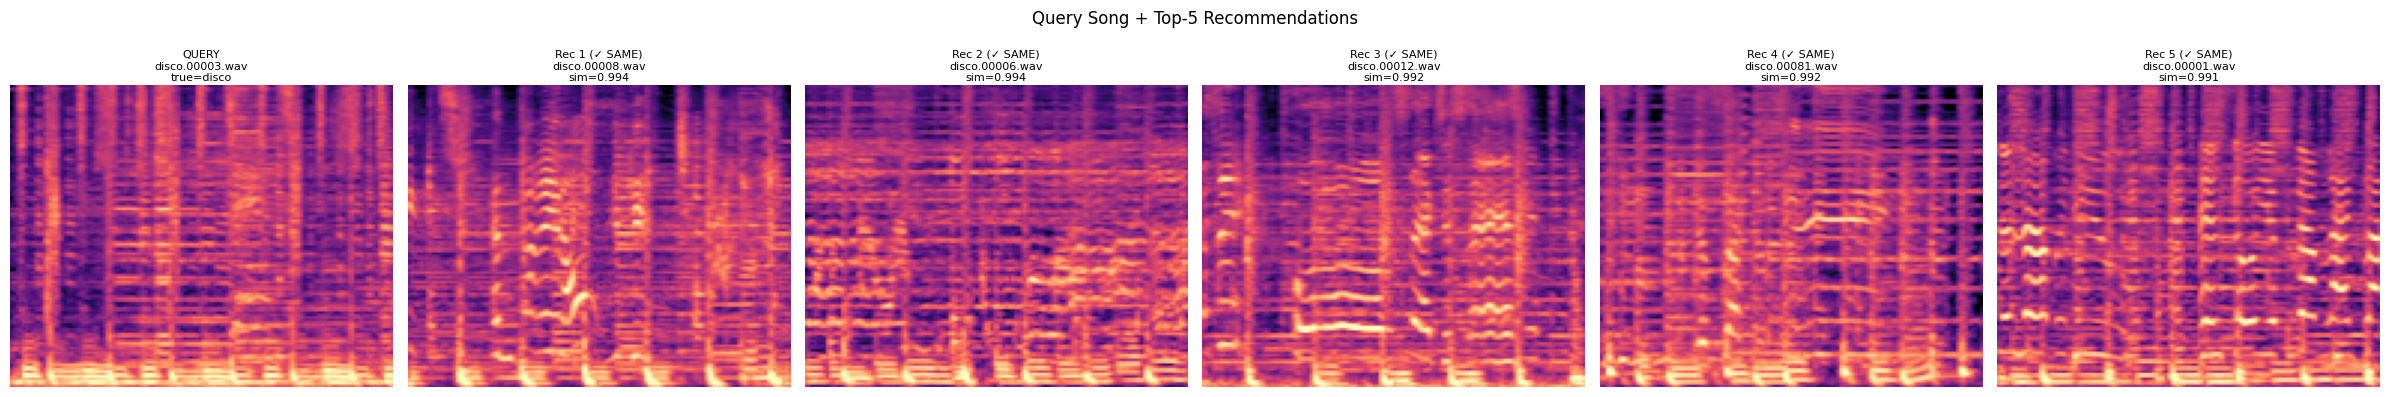

In [14]:
# ============================================================
# Cell 14 — Spectrogram visualisation of recommendations
# ============================================================

def show_spec_on_ax(ax, path, title):
    segs = list(extract_segments_from_track(path))
    if not segs:  return
    mid  = len(segs) // 2
    spec = segment_to_melspec(segs[mid][0])
    if spec is None:  return
    ax.imshow(spec.squeeze(), aspect="auto", origin="lower",
              cmap="magma", vmin=0, vmax=1)
    ax.set_title(title, fontsize=8, pad=3)
    ax.axis("off")

if result:
    n_recs = len(result["recommendations"])
    fig, axes = plt.subplots(1, n_recs + 1,
                              figsize=(4 * (n_recs + 1), 4))

    show_spec_on_ax(
        axes[0], query_path,
        f"QUERY\n{os.path.basename(query_path)}\ntrue={demo_genre}"
    )
    for i, rec in enumerate(result["recommendations"]):
        match = "✓ SAME" if rec["genre"] == demo_genre else f"≈ {rec['genre']}"
        show_spec_on_ax(
            axes[i+1], rec["file"],
            f"Rec {i+1} ({match})\n{os.path.basename(rec['file'])}\n"
            f"sim={rec['similarity']:.3f}"
        )

    plt.suptitle("Query Song + Top-5 Recommendations", fontsize=12)
    plt.tight_layout();  plt.show()


In [15]:
# ============================================================
# Cell 15 — Save model and artifacts
# ============================================================
final_model_path = os.path.join(MODEL_DIR, "music_genre_cnn_final.keras")
model.save(final_model_path)
print(f"Model saved : {final_model_path}")

artifact_path = os.path.join(ARTIFACT_DIR, "music_reco_artifacts.joblib")
joblib.dump({
    "label_encoder":     label_encoder,
    "pool_embs":         pool_embs,          # L2-normalised, shape (N, 128)
    "pool_paths":        pool_paths,
    "pool_labels":       pool_labels,
    "num_classes":       num_classes,
    # Audio hyperparameters — must be identical at inference time
    "SR":                SR,
    "SEG_DURATION":      SEG_DURATION,
    "HOP_DURATION":      HOP_DURATION,
    "TRACK_DURATION":    TRACK_DURATION,
    "N_MELS":            N_MELS,
    "FMAX":              FMAX,
    "IMG_SIZE":          IMG_SIZE,
    # Evaluation scores (informational)
    "seg_accuracy":      float(seg_acc),
    "track_accuracy":    float(track_acc),
    "macro_f1":          float(macro_f1),
}, artifact_path)
print(f"Artifacts  : {artifact_path}")
print("Save complete ✓")


Model saved : /content/music_reco_project/model/music_genre_cnn_final.keras
Artifacts  : /content/music_reco_project/artifacts/music_reco_artifacts.joblib
Save complete ✓


In [16]:
# ============================================================
# Cell 16 — Load saved model and run inference (fresh session safe)
# ============================================================
# This cell can be run after a Colab runtime restart.
# All hyperparameters are loaded from the artifact file,
# so there is no risk of train/inference preprocessing mismatch.

loaded_model    = tf.keras.models.load_model(final_model_path)
loaded_art      = joblib.load(artifact_path)

loaded_le       = loaded_art["label_encoder"]
loaded_pool_emb = loaded_art["pool_embs"]
loaded_pool_p   = loaded_art["pool_paths"]
loaded_pool_l   = loaded_art["pool_labels"]

# Restore audio hyperparameters from artifact (prevents silent mismatch)
_SR          = loaded_art["SR"]
_SEG_DUR     = loaded_art["SEG_DURATION"]
_HOP_DUR     = loaded_art["HOP_DURATION"]
_TRACK_DUR   = loaded_art["TRACK_DURATION"]
_N_MELS      = loaded_art["N_MELS"]
_FMAX        = loaded_art["FMAX"]
_IMG_SIZE    = loaded_art["IMG_SIZE"]

loaded_emb_model = tf.keras.Model(
    inputs  = loaded_model.inputs,
    outputs = loaded_model.get_layer("embedding").output
)

def recommend_loaded(query_path: str, top_n: int = 5):
    """Inference using loaded model — identical pipeline to training."""
    segs = list(extract_segments_from_track(
        query_path, sr=_SR, seg_dur=_SEG_DUR,
        hop_dur=_HOP_DUR, track_dur=_TRACK_DUR
    ))
    if not segs:
        print(f"[ERROR] No segments from {query_path}");  return None, None, []

    specs = []
    for seg, _ in segs:
        spec = segment_to_melspec(seg, sr=_SR, n_mels=_N_MELS,
                                  fmax=_FMAX, img_size=_IMG_SIZE)
        if spec is not None:
            specs.append(spec)
    if not specs:
        print("[ERROR] Feature extraction failed.");  return None, None, []

    specs_arr = np.array(specs, dtype=np.float32)

    probs      = loaded_model.predict(specs_arr, verbose=0, batch_size=64).mean(axis=0)
    pred_idx   = int(np.argmax(probs))
    pred_genre = loaded_le.inverse_transform([pred_idx])[0]
    confidence = float(probs[pred_idx])

    embs     = loaded_emb_model.predict(specs_arr, verbose=0, batch_size=64).mean(axis=0, keepdims=True)
    embs     = embs / (np.linalg.norm(embs) + 1e-8)

    sims     = cosine_similarity(embs, loaded_pool_emb)[0]
    sorted_p = np.argsort(sims)[::-1]

    query_abs = os.path.abspath(query_path)
    recs = []
    for pos in sorted_p:
        if os.path.abspath(loaded_pool_p[pos]) == query_abs:
            continue
        recs.append({
            "file":       loaded_pool_p[pos],
            "genre":      loaded_pool_l[pos],
            "similarity": float(sims[pos])
        })
        if len(recs) >= top_n:
            break

    return pred_genre, confidence, recs

# ── Demo from test set ────────────────────────────────────────────────────────
demo2_genre = random.choice(sorted(genre_to_test_tracks.keys()))
demo2_path  = random.choice(genre_to_test_tracks[demo2_genre])

print(f"Query file  : {os.path.basename(demo2_path)}  (true: {demo2_genre})")
g2, c2, r2 = recommend_loaded(demo2_path, top_n=5)
print(f"Predicted   : {g2}  (confidence {c2:.4f})")
print("\nTop-5 recommendations:")
for i, rec in enumerate(r2, 1):
    match = "✓" if rec["genre"] == demo2_genre else " "
    print(f"  {i}. [{match}] {os.path.basename(rec['file']):<30s}  "
          f"genre={rec['genre']:<12s}  sim={rec['similarity']:.4f}")


Query file  : jazz.00020.wav  (true: jazz)
Predicted   : jazz  (confidence 0.7869)

Top-5 recommendations:
  1. [✓] jazz.00021.wav                  genre=jazz          sim=0.9775
  2. [✓] jazz.00038.wav                  genre=jazz          sim=0.9759
  3. [✓] jazz.00051.wav                  genre=jazz          sim=0.9753
  4. [✓] jazz.00018.wav                  genre=jazz          sim=0.9707
  5. [✓] jazz.00043.wav                  genre=jazz          sim=0.9680


In [17]:
# ============================================================
# Cell 17 — Project summary
# ============================================================
print("=" * 65)
print("  MUSIC RECOMMENDATION SYSTEM — FINAL SUMMARY")
print("=" * 65)
print(f"  Dataset          : GTZAN ({len(df_tracks)} tracks, {num_classes} genres)")
print(f"  Segments/track   : {int(len(X_train)/len(tracks_train))} "
      f"(3 s, hop 1.5 s, leakage-free track split)")
print(f"  Train segments   : {len(X_train):,}")
print(f"  Val   segments   : {len(X_val):,}")
print(f"  Test  segments   : {len(X_test):,}")
print(f"  Segment accuracy : {seg_acc*100:.2f} %")
print(f"  Track accuracy   : {track_acc*100:.2f} %  (majority vote)")
print(f"  Macro F1 Score   : {macro_f1*100:.2f} %")
print(f"  Embedding dim    : 128 (averaged per track, L2-normalised)")
print(f"  Recommendation   : Cosine similarity, genre-agnostic pool")
print(f"  Model saved      : {final_model_path}")
print("=" * 65)
print("  Pipeline:")
print("    Audio track (30 s)")
print("    → 19 overlapping 3 s segments  (hop=1.5 s)")
print("    → Mel-spectrogram (128 mel bins, fmax=8000)")
print("    → Per-segment z-score → clip ±3σ → scale [0,1]")
print("    → Resize 128×128×1 (nearly lossless for 3 s clips)")
print("    → ResNet-style CNN → softmax(10) genre prediction")
print("    → Dense-128 embedding → average over segments")
print("    → L2-normalise → cosine similarity → top-N recs")
print("=" * 65)


  MUSIC RECOMMENDATION SYSTEM — FINAL SUMMARY
  Dataset          : GTZAN (999 tracks, 10 genres)
  Segments/track   : 19 (3 s, hop 1.5 s, leakage-free track split)
  Train segments   : 13,281
  Val   segments   : 2,850
  Test  segments   : 2,850
  Segment accuracy : 70.53 %
  Track accuracy   : 74.00 %  (majority vote)
  Macro F1 Score   : 72.36 %
  Embedding dim    : 128 (averaged per track, L2-normalised)
  Recommendation   : Cosine similarity, genre-agnostic pool
  Model saved      : /content/music_reco_project/model/music_genre_cnn_final.keras
  Pipeline:
    Audio track (30 s)
    → 19 overlapping 3 s segments  (hop=1.5 s)
    → Mel-spectrogram (128 mel bins, fmax=8000)
    → Per-segment z-score → clip ±3σ → scale [0,1]
    → Resize 128×128×1 (nearly lossless for 3 s clips)
    → ResNet-style CNN → softmax(10) genre prediction
    → Dense-128 embedding → average over segments
    → L2-normalise → cosine similarity → top-N recs
